# Tutorial 6: Brute Optimization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brute

# Import high-level functions and data classes
from vital.module_tidal import process_tidal_data
from vital.module_rotor import RotorData
from vital.module_rotor_simulation import RotorSimulation
from vital.module_vessel import VesselData
from vital.module_constraint_checker import ConstraintChecker
from vital.module_lcoe import LCOEData, LCOECalculator

# -------------------------------
# Tidal Data Processing
# -------------------------------

station = "COI1210"  # NOAA station identifier
startdate = "2020-01-01"  # Start date for tidal data retrieval
tidal = process_tidal_data(station=station, startdate=startdate)

# print(f"Tidal Data for Station {tidal.station_name}:")
# print(f"  Mooring Distance (m): {tidal.mooring_distance}")
# print(f"  Latitude (rad): {tidal.latitude}")
# print(f"  Longitude (rad): {tidal.longitude}")
# print(f"  Nearest City: {tidal.nearest_city}")
# print(f"  Cable Length (m): {tidal.cable_length}")

# plt.figure()
# plt.plot(tidal.times, tidal.flow_speeds)
# plt.xlabel("Time (s)", fontsize=12)
# plt.ylabel("Flow Speed (m/s)", fontsize=12)
# plt.title(f"Flow Speeds for Station {tidal.station_name}", fontsize=14)
# plt.show()

# -------------------------------
# Rotor Data Processing
# -------------------------------

RotorPerformanceFile = "../data/Sitkana_rotor_data_blade_2.txt"
rotor = RotorData(RotorPerformanceFile)

# print("Rotor Data:")
# print(f"  Optimal Cp: {rotor.CpOpt}")
# print(f"  Optimal TSR: {rotor.TSROpt}")

# -------------------------------
# Simulation Configuration
# -------------------------------

config = {
    'Radius': 0.5,
    'Prated': 1000.0,
    'Trated': np.inf,
    'dHub': 7.0,
    'number_of_turbines': 6,
    'dMoor': tidal.mooring_distance,
    'Uinf': tidal.flow_speeds,
    't': tidal.times,
    'CpFunc': rotor.get_cp,
    'CqFunc': rotor.get_cq,
    'CtFunc': rotor.get_ct,
    'CpOpt': rotor.CpOpt,
    'TSROpt': rotor.TSROpt,
    'TSRmax': rotor.TSRmax,
    'Ng': 50,
    'Kt': 1.5,
    'Rw': 0.5,
    'J_d': 1,
    'B_d': 1,
    'J_r': 10,
}

# # -------------------------------
# # Rotor Simulation
# # -------------------------------

# rotor_sim = RotorSimulation(config)
# rotor_sim.simulate()
# result = rotor_sim.get_results()

# -------------------------------
# Vessel Data Processing
# -------------------------------

user_vessel_properties = {
    'Xm': 5.77,
    'Zm': 1.65,
    'Kphi': 1.95e6,
    'theta': np.radians(45.0),
    'phi': np.radians(20.0),
    'area': 9.5,
    'Cd': 1.0,
}



# # -------------------------------
# # Constraint Checking
# # -------------------------------

# constraint_checker = ConstraintChecker(rotor, config, vessel, result)
# constraints = {
#     "Power Constraint": constraint_checker.check_power_constraint(),
#     "Depth Constraint": constraint_checker.check_depth_constraint(),
#     "Cavitation Constraint": constraint_checker.check_cavitation_constraint(),
#     "Pitch Constraint": constraint_checker.check_pitch_constraint(),
# }

# print("Constraint Results:")
# for name, satisfied in constraints.items():
#     print(f"  {name}: {'Satisfied' if satisfied else 'Not Satisfied'}")

# # -------------------------------
# # LCOE Calculation
# # -------------------------------

# data = LCOEData(
#     tidal, config, vessel, result,
#     turbinelifetime=10,
#     discount_rate=0.1,
#     turbulence_intensity=0.0,
#     customer='customer_B',
#     application='battery_charging',
#     BatteryCapacity_kWh=10.0
# )
# calculator = LCOECalculator(data)

# lcoe = calculator.calculate_lcoe()
# print(f"LCOE: {lcoe:.2f}")

# print("Annual Energy Production:")
# calculator.list_annual_energy()

# print("CAPEX:")
# total_capex = calculator.calculate_total_capex()
# calculator.list_capex()

# print("OPEX Components:")
# calculator.list_opex(total_capex)

# -------------------------------
# Optimization
# -------------------------------


/Users/akeow/opt/anaconda3/envs/VITAL_env/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/akeow/opt/anaconda3/envs/VITAL_env/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/akeow/opt/anaconda3/envs/VITAL_env/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#t

Solving the initial value problem (IVP) for turbine dynamics...
Solving the initial value problem (IVP) for turbine dynamics...
IVP solving complete.
Configuration Failed: Radius=1.00, Prated=1000.00, dHub=3.00, numTurbine=2.00
Violated Constraints: Power Constraint
Solving the initial value problem (IVP) for turbine dynamics...
IVP solving complete.
Configuration Failed: Radius=1.00, Prated=1000.00, dHub=3.00, numTurbine=6.00
Violated Constraints: Power Constraint, Pitch Constraint
Solving the initial value problem (IVP) for turbine dynamics...
IVP solving complete.
Solving the initial value problem (IVP) for turbine dynamics...
Configuration Failed: Radius=1.00, Prated=1000.00, dHub=8.00, numTurbine=4.00
Violated Constraints: Power Constraint, Pitch Constraint
Solving the initial value problem (IVP) for turbine dynamics...
IVP solving complete.
Configuration Failed: Radius=1.00, Prated=1000.00, dHub=13.00, numTurbine=2.00
Violated Constraints: Power Constraint
IVP solving complete.
S

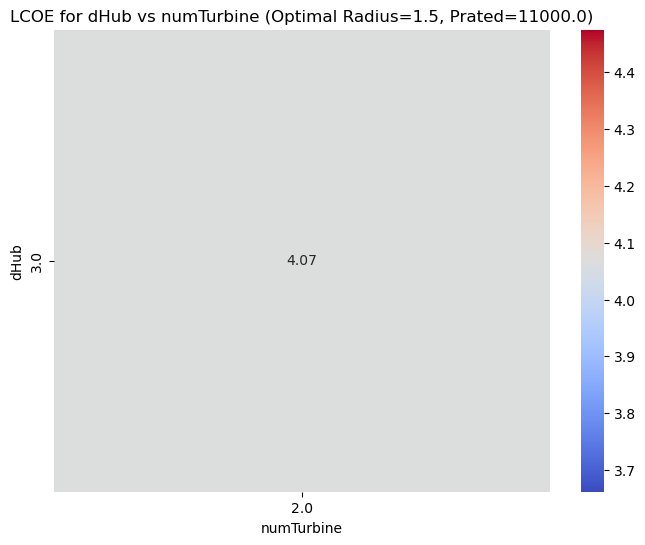

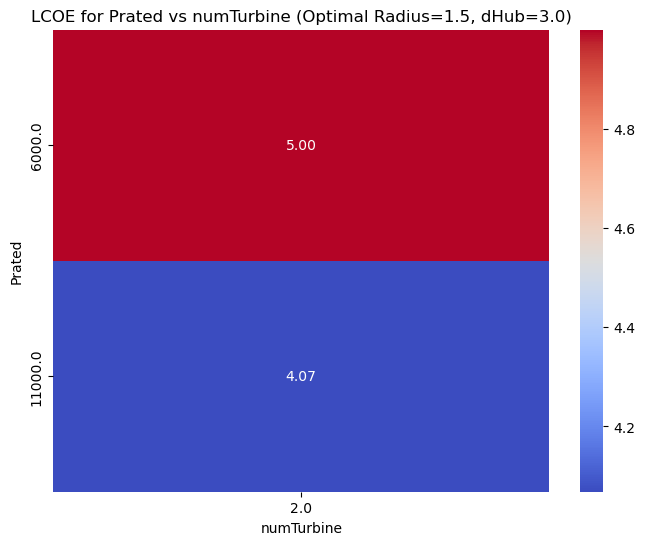

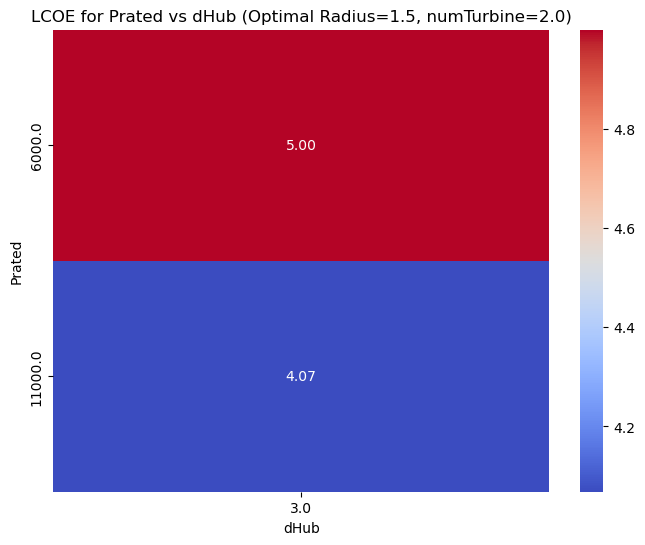

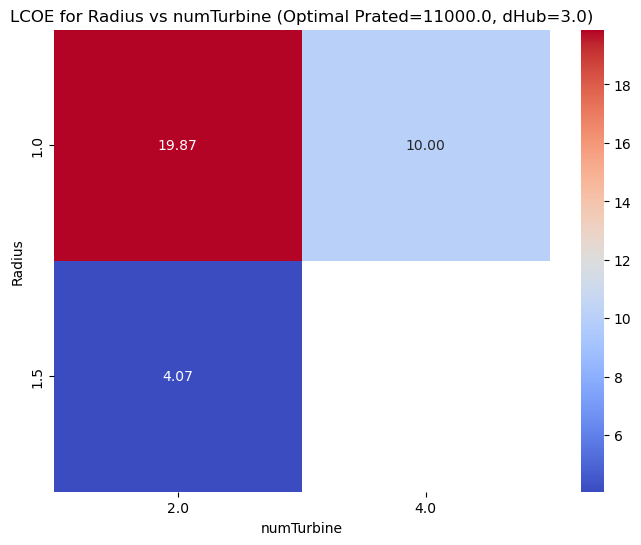

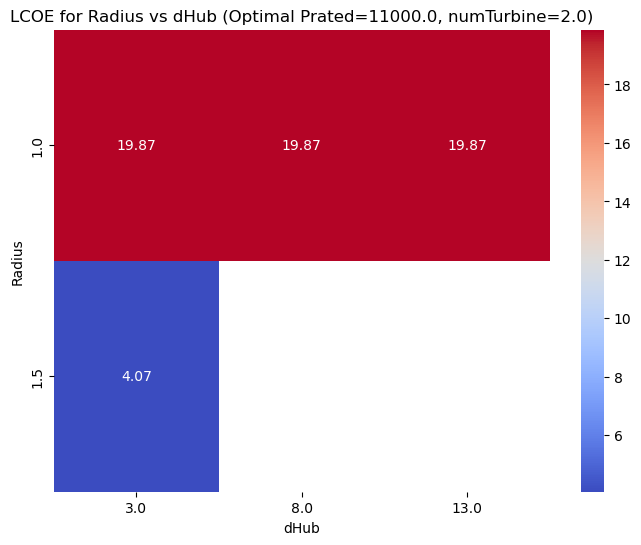

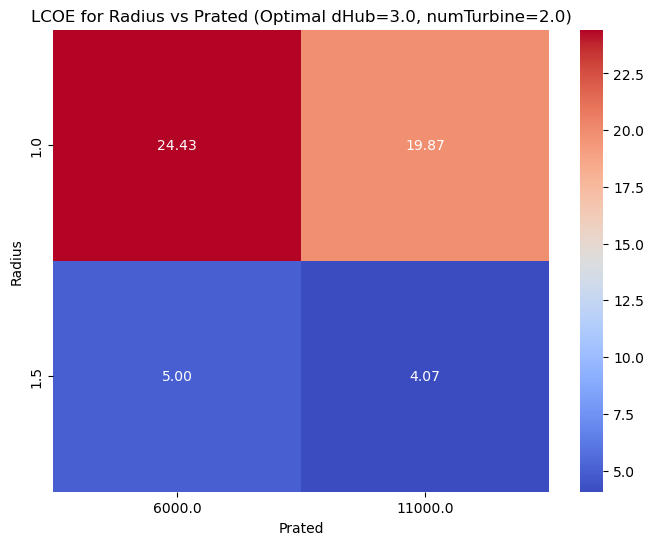

In [2]:
from vital.module_lcoe_optimizer import LCOEOptimizer

# Example bounds for optimization
bounds = {
    'Radius': (1, 2.1, 0.5),  # Min, Max, Step
    'Prated': (1000.0, 12000.0, 5000.0),
    'dHub': (3, 14, 5),
    'numTurbine': (2, 7, 2)
}

# Initialize optimizer
optimizer = LCOEOptimizer(tidal, rotor, config, user_vessel_properties)

# Perform optimization
optimal_params, optimal_lcoe, brute_output = optimizer.optimize(bounds)
optimizer.plot_heatmaps(brute_output, bounds)
